## Clarke Wright Algorithm in Multi Depot Vehicle Routing Problem (MDVRP)

In [18]:
# graf awal
import numpy as np
import math
import networkx as nx
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter
import random
import pandas as pd

n = 20
INF = 10**6

adj = [[INF]*n for _ in range(n)]
for i in range(n):
    adj[i][i] = 0

# Fungsi untuk menghitung jarak Euclidean
def euclidean_distance(pos1, pos2):
    return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

# Posisi node
pos = {
    0: (3.38, 2.07),
    1: (1.21, 3.66),
    2: (2.58, 3.92),
    3: (2.84, 2.99),
    4: (3.89, 3.11),
    5: (2.07, 3.21),
    6: (2.28, 2.17),
    7: (2.13, 1.48),
    8: (3.87, 4.06),
    9: (1.38, 2.77),
    10: (1.63, 2.08),
    11: (3.28, 4.56),
    12: (2.23, 4.81),
    13: (1.03, 4.52),
    14: (3.28, 3.81),
    15: (0.93, 1.38),
    16: (1.98, 0.68),
    17: (0.83, 2.48),
    18: (0.63, 3.97),
    19: (0.73, 3.18),
}

demands = [0, 0, 4, 8, 6, 3, 7, 10, 5, 9, 2, 11, 8, 12, 4, 7, 5, 6, 9, 3]
capacity = 30 
depot = [0, 1]

edges_template = [
    (0, 16, 0), (0, 7, 0), (0, 3, 0),
    (14, 2, 0), (14, 4, 0), (14, 11, 0),
    (2, 3, 0), (2, 12, 0), (2, 1, 0),
    (3, 4, 0), (3, 5, 0), (3, 6, 0),
    (4, 0, 0),
    (5, 6, 0), (5, 9, 0), (5, 1, 0),
    (6, 7, 0), (6, 0, 0), (6, 10, 0),
    (7, 10, 0), (7, 16, 0),
    (8, 14, 0), (8, 11, 0),
    (9, 10, 0), (9, 1, 0), (9, 17, 0),
    (10, 15, 0),
    (11, 12, 0),
    (12, 13, 0), (12, 1, 0),
    (13, 1, 0), (13, 18, 0),
    (15, 16, 0), (15, 17, 0),
    (17, 18, 0),
    (18, 19, 0),
    (19, 1, 0)
]

edges = []
for nodeA, nodeB, _ in edges_template:
    d = euclidean_distance(pos[nodeA], pos[nodeB])
    cost = round(d * 10)
    edges.append((nodeA, nodeB, cost))


for (i,j,w) in edges:
    adj[i][j] = w
    adj[j][i] = w

dist = np.array(adj, dtype=float)
for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i,j] > dist[i,k] + dist[k,j]:
                dist[i,j] = dist[i,k] + dist[k,j]

dist = np.rint(dist).astype(int)

df_dist = pd.DataFrame(dist, index=range(n), columns=range(n))

print("Distance Matrix:")
df_dist

Distance Matrix:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,29,21,11,12,19,11,14,27,25,18,28,31,38,21,28,20,31,44,36
1,29,0,14,18,29,10,21,24,27,9,16,26,15,9,21,26,32,15,15,7
2,21,14,0,10,16,18,20,27,13,23,27,14,10,22,7,37,35,29,29,21
3,11,18,10,0,11,8,10,17,23,16,17,24,20,27,17,27,25,22,33,25
4,12,29,16,11,0,19,21,26,15,27,28,16,26,38,9,38,32,33,44,36
5,19,10,18,8,19,0,11,18,31,8,15,32,25,19,25,25,26,14,25,17
6,11,21,20,10,21,11,0,7,33,14,7,34,30,30,27,17,15,20,35,28
7,14,24,27,17,26,18,7,0,40,15,8,41,37,33,34,18,8,21,36,31
8,27,27,13,23,15,31,33,40,0,36,40,8,19,31,6,50,47,42,38,34
9,25,9,23,16,27,8,14,15,36,0,7,35,24,18,30,17,23,6,21,16


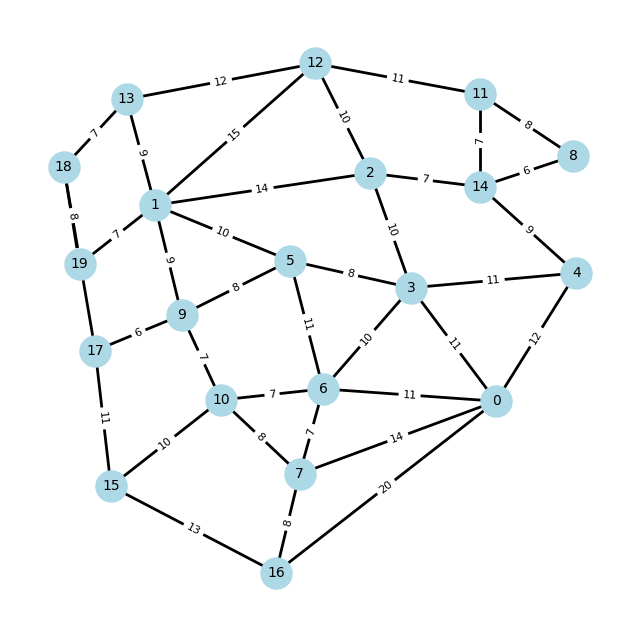

In [19]:
G = nx.Graph()

for (u, v, w) in edges:
    G.add_edge(u, v, weight=w)

plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')

nx.draw_networkx_edges(G, pos, width=2)

nx.draw_networkx_labels(G, pos, font_size=10)

edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.axis('off')
plt.show()


In [20]:
group = [[] for _ in range(len(depot))]

for ci in range(n):
    if ci in depot:
        continue
    
    nearest_depot_index = None
    nearest_distance = float('inf')

    for idx, d in enumerate(depot):
        jarak = dist[ci][d]

        if jarak < nearest_distance:
            nearest_distance = jarak
            nearest_depot_index = idx

    group[nearest_depot_index].append(ci)

for i in range(len(depot)):
    print(f"group untuk depot {depot[i]}:", group[i])

group untuk depot 0: [3, 4, 6, 7, 8, 14, 16]
group untuk depot 1: [2, 5, 9, 10, 11, 12, 13, 15, 17, 18, 19]


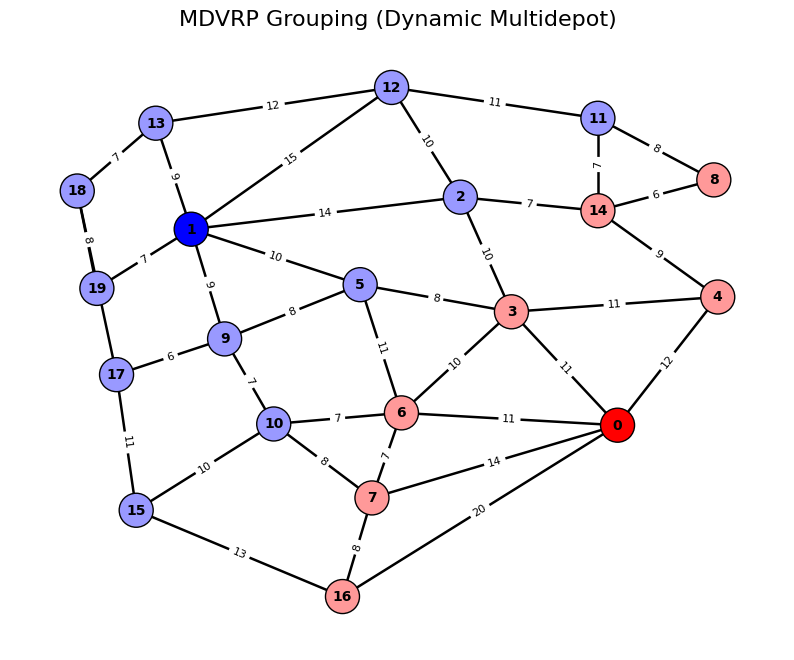

In [21]:
G = nx.Graph()
G.add_nodes_from(range(n))
for (u, v, w) in edges:
    G.add_edge(u, v, weight=w)

plt.figure(figsize=(10, 8))

depot_colors = ["red", "blue", "green", "purple", "orange", "brown"]
group_colors = ["#ff9999", "#9999ff", "#99ff99", "#d699ff", "#ffd699", "#ffccff"]

node_colors = []

for i in range(n):
    if i in depot:
        idx = depot.index(i)
        node_colors.append(depot_colors[idx % len(depot_colors)])
    else:
        found = False
        for k in range(len(group)):
            if i in group[k]:
                node_colors.append(group_colors[k % len(group_colors)])
                found = True
                break
        if not found:
            node_colors.append("gray") 

nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_colors, edgecolors="black")

nx.draw_networkx_edges(G, pos, width=1.8)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

edge_labels = {(u, v): w for u, v, w in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("MDVRP Grouping (Dynamic Multidepot)", fontsize=16)
plt.axis("off")
plt.show()

In [22]:
def compute_savings_table(dist, depot, group):
    rows = []

    for idx_i, i in enumerate(group):
        for idx_j, j in enumerate(group):
            if idx_i >= idx_j:
                continue
            Sij = dist[depot][i] + dist[depot][j] - dist[i][j]
            rows.append([i, j, dist[depot][i], dist[depot][j], dist[i][j], Sij])

    df = pd.DataFrame(rows, columns=[
        "i", "j",
        f"D({depot},i)", f"D({depot},j)", "D(i,j)",
        "Saving S(i,j)"
    ])

    df_sorted = df.sort_values(by="Saving S(i,j)", ascending=False)

    return df, df_sorted

for d in depot:
    df, df_sorted = compute_savings_table(dist, d, group[d])
    display(df)

,i,j,"D(0,i)","D(0,j)","D(i,j)","Saving S(i,j)"
0,3,4,11,12,11,12
1,3,6,11,11,10,12
2,3,7,11,14,17,8
3,3,8,11,27,23,15
4,3,14,11,21,17,15
5,3,16,11,20,25,6
6,4,6,12,11,21,2
7,4,7,12,14,26,0
8,4,8,12,27,15,24
9,4,14,12,21,9,24


,i,j,"D(1,i)","D(1,j)","D(i,j)","Saving S(i,j)"
0,2,5,14,10,18,6
1,2,9,14,9,23,0
2,2,10,14,16,27,3
3,2,11,14,26,14,26
4,2,12,14,15,10,19
5,2,13,14,9,22,1
6,2,15,14,26,37,3
7,2,17,14,15,29,0
8,2,18,14,15,29,0
9,2,19,14,7,21,0


In [23]:
for d in depot:
    df, df_sorted = compute_savings_table(dist, d, group[d])
    display(df_sorted)

,i,j,"D(0,i)","D(0,j)","D(i,j)","Saving S(i,j)"
18,8,14,27,21,6,42
17,7,16,14,20,8,26
8,4,8,12,27,15,24
9,4,14,12,21,9,24
11,6,7,11,14,7,18
14,6,16,11,20,15,16
4,3,14,11,21,17,15
3,3,8,11,27,23,15
0,3,4,11,12,11,12
1,3,6,11,11,10,12


,i,j,"D(1,i)","D(1,j)","D(i,j)","Saving S(i,j)"
30,10,15,16,26,10,32
34,11,12,26,15,11,30
49,15,17,26,15,11,30
3,2,11,14,26,14,26
4,2,12,14,15,10,19
24,9,17,9,15,6,18
19,9,10,9,16,7,18
23,9,15,9,26,17,18
31,10,17,16,15,13,18
47,13,18,9,15,7,17


In [ ]:
G = nx.Graph()
for i in range(n):
    G.add_node(i)
for (i,j,w) in edges:
    G.add_edge(i,j,weight=w)

def clarke_wright(dist, demands, capacity, depot, group):
    N = len(group)

    routes = {i:[depot, i, depot] for i in group if i != depot}

    savings = []
    for idx_i, i in enumerate(group):
        for idx_j, j in enumerate(group):
            if idx_i >= idx_j:
                continue
            Sij = dist[depot][i] + dist[depot][j] - dist[i][j]
            savings.append((Sij, i, j))

    savings.sort(reverse=True)

    snapshots = []

    initial_edges = []
    for r in routes.values():
        initial_edges.extend(list(zip(r[:-1], r[1:])))
    snapshots.append(initial_edges)

    used_savings = []

    for S, i, j in savings:

        route_i = None
        route_j = None
        for r in routes.values():
            if r[-2] == i:
                route_i = r
            if r[1] == j:
                route_j = r

        if route_i is None or route_j is None:
            continue
        if route_i == route_j:
            continue

        load_i = sum(demands[x] for x in route_i[1:-1])
        load_j = sum(demands[x] for x in route_j[1:-1])
        if load_i + load_j > capacity:
            continue

        new_route = route_i[:-1] + route_j[1:]

        key_i = [k for k,v in routes.items() if v==route_i][0]
        key_j = [k for k,v in routes.items() if v==route_j][0]
        del routes[key_i]
        del routes[key_j]

        routes[i] = new_route
        used_savings.append((S, i, j))  

        edges_step = []
        for r in routes.values():
            edges_step.extend(list(zip(r[:-1], r[1:])))
        snapshots.append(edges_step)

    return list(routes.values()), snapshots, savings, used_savings

def visualize_steps(G, pos, progress, color="red"):

    steps = len(progress)
    cols = 4
    rows = math.ceil(steps/cols)

    plt.figure(figsize=(cols*4, rows*4))

    for step, edges_step in enumerate(progress):
        plt.subplot(rows, cols, step+1)
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color='white', edgecolors='black')
        nx.draw_networkx_labels(G, pos)
        nx.draw_networkx_edges(G, pos, alpha=0.3)
        nx.draw_networkx_edges(G, pos, edgelist=edges_step, edge_color=color, width=3)
        plt.title(f"Step {step+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def savings_table(savings, used_savings):
    df = pd.DataFrame(savings, columns=["Saving", "i", "j"])
    df["Used"] = "No"

    used_set = {(i,j,S) for (S,i,j) in used_savings}

    df["Used"] = df.apply(lambda row:
                          "Yes" if (row["i"], row["j"], row["Saving"]) in 
                          {(i,j,S) for (S,i,j) in used_savings}
                          else "No", axis=1)

    df = df.sort_values(by="Saving", ascending=False).reset_index(drop=True)
    return df

for d in depot:
    routes, progress, savings, used_savings = clarke_wright(dist, demands, capacity, d, group[d])

    df_saving = savings_table(savings, used_savings)

    df_used = df_saving[df_saving["Used"] == "Yes"].sort_values(by="Saving", ascending=False)
    df_used
    

NameError: name 'show' is not defined

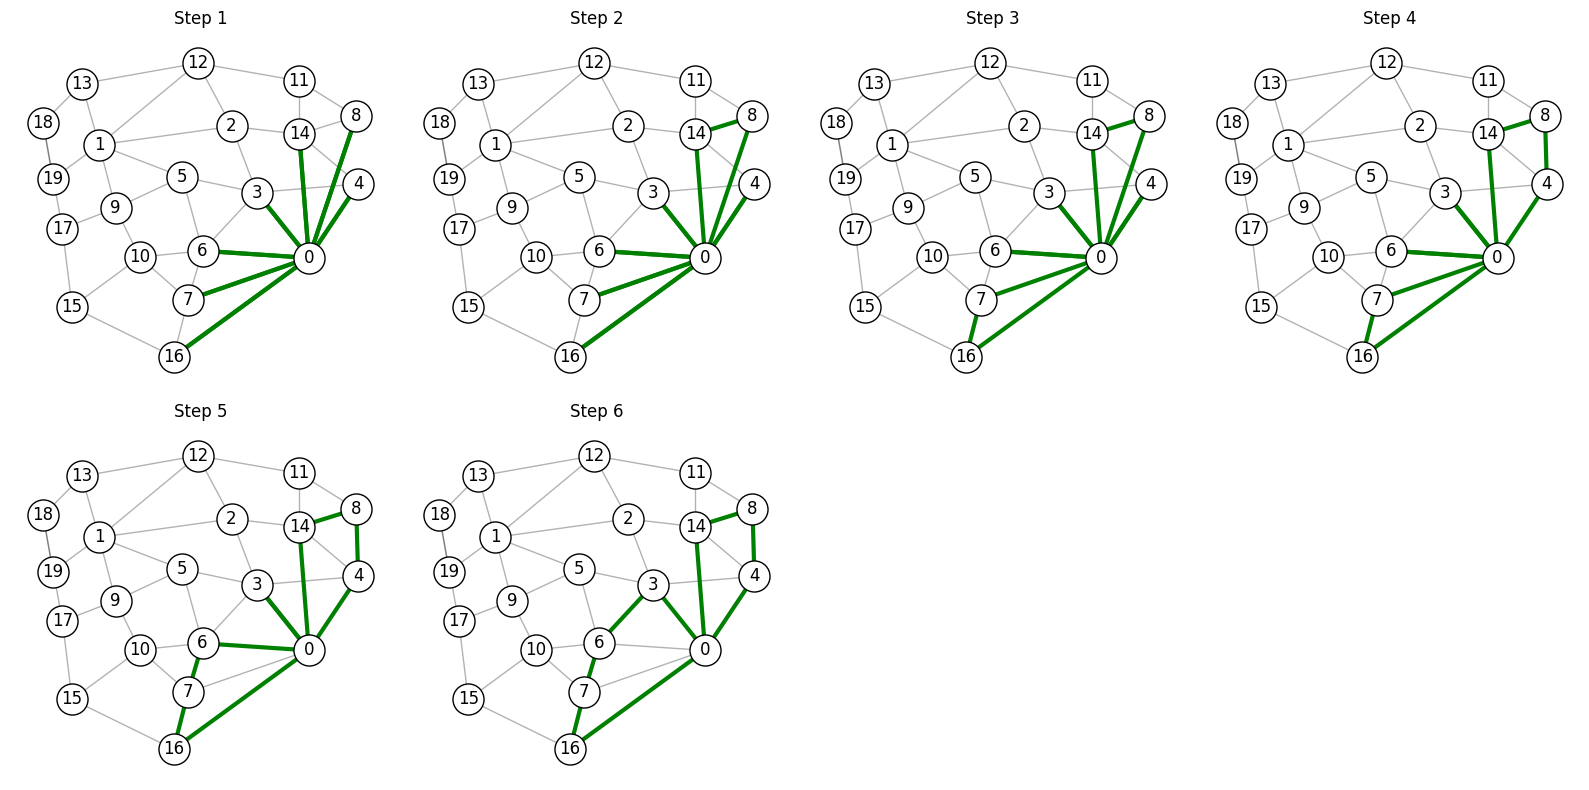

Final routes:
[0, 4, 8, 14, 0]
[0, 3, 6, 7, 16, 0]


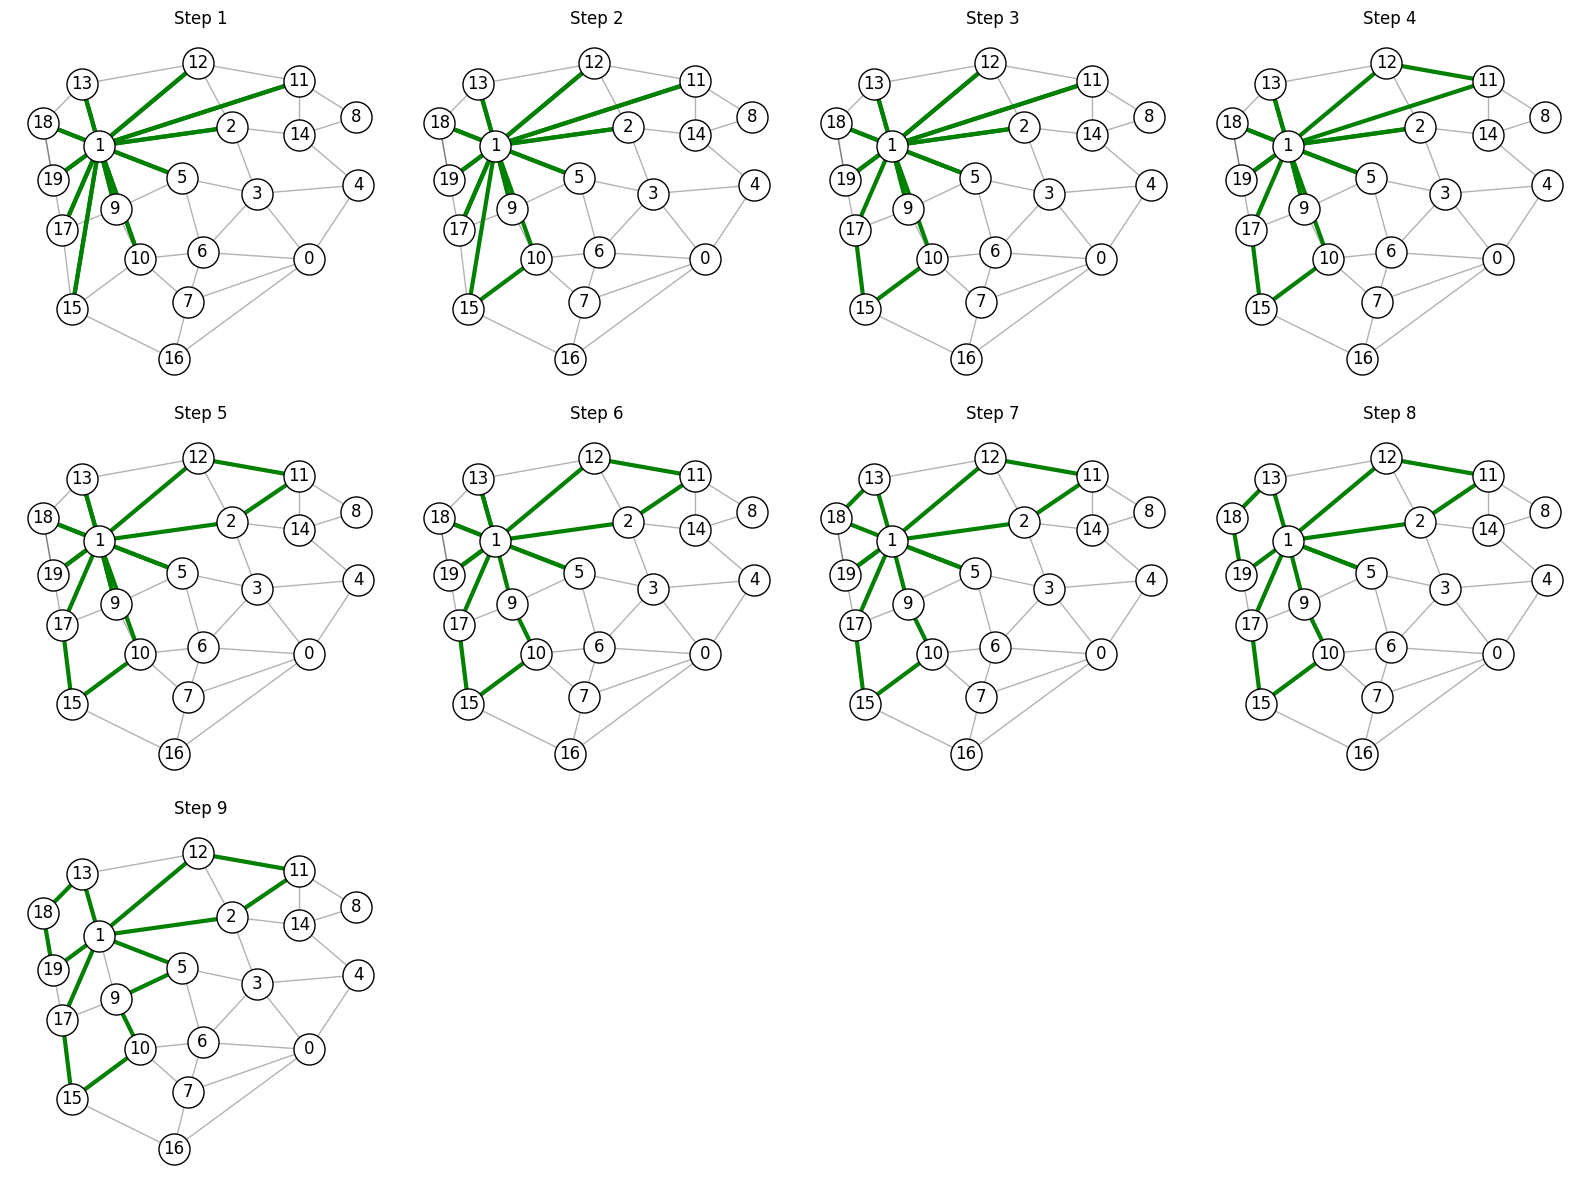

Final routes:
[1, 2, 11, 12, 1]
[1, 13, 18, 19, 1]
[1, 5, 9, 10, 15, 17, 1]


In [25]:
for d in depot:
    routes, progress, savings, used_savings = clarke_wright(dist, demands, capacity, d, group[d])

    visualize_steps(G, pos, progress, color="green")

    print("Final routes:")
    for r in routes:
        print(r)